In [259]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [260]:
df = pd.read_csv('E:/Courses/DS/Dataset/student.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,very good,medium,high,very low,very low,good,6,5,6,6
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,excellent,medium,medium,very low,very low,good,4,5,5,6
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,very good,medium,low,low,medium,good,10,7,8,10
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,good,low,low,very low,very low,excellent,2,15,14,15
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,very good,medium,low,very low,low,excellent,4,6,10,10


In [261]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [262]:
df['G3'].sort_values(ascending=True).unique()

array([ 0,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20])

In [263]:
df['Medu'].unique()

<StringArray>
[             'higher education', 'primary education (4th grade)',
           'secondary education',              '5th to 9th grade',
                          'none']
Length: 5, dtype: str

### Function to encode data

In [264]:
def label_data(dataframe, col, *args):
    encode_value = {}

    for idx, val in enumerate(args):
        encode_value[val] = idx

    dataframe[f'{col}_id'] = dataframe[col].map(encode_value)

### Convert continuous data to categorical data

In [265]:
# 0,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20
def convert_grade(grade):
    if grade >= 17 and grade <= 20:
        return 'A'
    elif grade >= 13 and grade < 17:
        return 'B'
    elif grade >= 8 and grade < 13:
        return 'C'
    else:
        return 'Fail'

In [266]:
df['Grade'] = df['G3'].apply(convert_grade)

In [267]:
# ['Medu', 'Fedu', 'traveltime', 'studytime','failures', 'schoolsup', 'famsup', 'activities', 'internet',
# 'freetime', 'goout', 'Dalc', 'Walc', 'health','absences', 'G1', 'G2']

In [268]:
le_columns = ['schoolsup', 'famsup', 'activities', 'internet']

In [269]:
le = LabelEncoder()
for col in le_columns:
    df[f'{col}_id'] = le.fit_transform(df[col])

In [270]:
label_data(df, 'Grade', 'Fail', 'C', 'B', 'A')

In [271]:
label_data(df, 'Medu', 'none', 'primary education (4th grade)', '5th to 9th grade', 'secondary education',
          'higher education')

In [272]:
label_data(df, 'Fedu', 'none', 'primary education (4th grade)', '5th to 9th grade', 'secondary education',
          'higher education')

In [273]:
label_data(df, 'traveltime', '<15 min.', '15 to 30 min.', '30 min. to 1 hour', '>1 hour')

In [274]:
label_data(df, 'studytime', '<2 hours', '2 to 5 hours', '5 to 10 hours', '>10 hours')

In [275]:
label_data(df, 'freetime', 'very low', 'low', 'medium', 'high', 'very high')

In [276]:
label_data(df, 'goout', 'very low', 'low', 'medium', 'high', 'very high')

In [277]:
label_data(df, 'Dalc', 'very low', 'low', 'medium', 'high', 'very high')

In [278]:
label_data(df, 'Walc', 'very low', 'low', 'medium', 'high', 'very high')

In [279]:
label_data(df, 'health', 'very bad', 'bad', 'good', 'very good', 'excellent')

In [280]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Grade', 'schoolsup_id',
       'famsup_id', 'activities_id', 'internet_id', 'Grade_id', 'Medu_id',
       'Fedu_id', 'traveltime_id', 'studytime_id', 'freetime_id', 'goout_id',
       'Dalc_id', 'Walc_id', 'health_id'],
      dtype='str')

In [281]:
# Feature and Target

features = ['Medu_id', 'Fedu_id', 'traveltime_id', 'studytime_id', 'failures', 
            'schoolsup_id', 'famsup_id', 'internet_id',
            'freetime_id', 'goout_id', 'Dalc_id', 'Walc_id', 'health_id',
             'absences', 'G1', 'G2']

target = 'Grade_id'

In [282]:
x = df[features]
y = df[target]

In [283]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [284]:
scaler = StandardScaler()

In [285]:
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

In [286]:
# Elbow Method

# Elbow method - to find number of optimal neighbours

k_range = range(1,21)
error_rate = []

In [287]:
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_scale, y_train)
    knn_pred = knn.predict(x_test_scale)
    # total wrong prediction / total test values
    error_rate.append(np.mean(y_test != knn_pred))

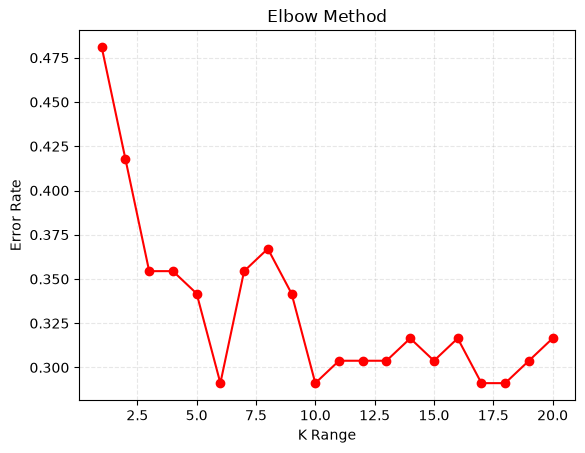

In [288]:
# Visualization for Elbow Method
plt.plot(k_range, error_rate, color = 'red', marker = 'o')
plt.xlabel('K Range')
plt.ylabel('Error Rate')
plt.title('Elbow Method')
plt.grid(linestyle = 'dashed', alpha = 0.3)

In [289]:
k = 3

In [290]:
model = KNeighborsClassifier(n_neighbors=k)

# Train the model
model.fit(x_train_scale, y_train)

# Make predictions
y_pred = model.predict(x_test_scale)

In [291]:
cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [292]:
print(cr)

              precision    recall  f1-score   support

           0       0.67      0.43      0.52        14
           1       0.67      0.79      0.73        39
           2       0.59      0.62      0.60        21
           3       0.50      0.20      0.29         5

    accuracy                           0.65        79
   macro avg       0.61      0.51      0.54        79
weighted avg       0.64      0.65      0.63        79



In [293]:
print(cm)

[[ 6  7  1  0]
 [ 3 31  5  0]
 [ 0  7 13  1]
 [ 0  1  3  1]]


<Axes: >

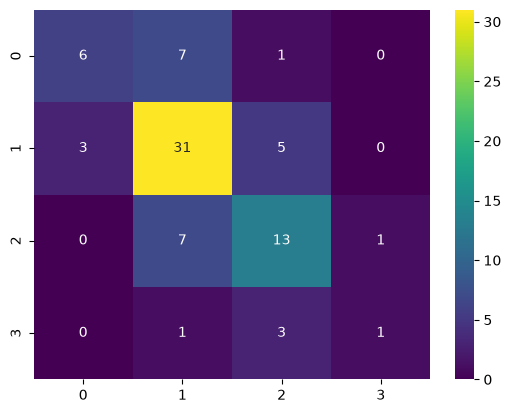

In [294]:
# visualization

sns.heatmap(cm, annot = True, cmap = 'viridis')